# 03 – Unsupervised Learning: Klustring av livsstilsvariabler

Mål: se om studenternas livsstilsvariabler (utan att titta på `Depression`) bildar
naturliga grupper - och om dessa grupper i så fall råkar hänga ihop med Depression-utfallet.
Bygger på `student_depression_clean.csv` från `01_Dataforberedelse.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Visuell stil

Samma palett och stil som i `02_EDA.ipynb`, plus fyra fasta klusterfärger (samma
ordning som resten av vårt projekts designsystem - blå, orange, turkos, gul).

In [2]:
# Fast, återanvändbar färgpalett - ett blå/röd-par som är valt för att gå att skilja
# på även för färgblinda.
PALETTE = {
    "blue": "#2a78d6",     # serie 1 / ena polen i diverging-skalor
    "red": "#e34948",      # serie 2 / andra polen i diverging-skalor
    "orange": "#eb6834",   # serie 3
    "neutral": "#f0efec",  # mittpunkt i diverging-skalor
    "grid": "#e1e0d9",     # hårfina gridlines
    "ink": "#0b0b0b",      # primär textfärg
    "muted": "#898781",    # sekundär text (oanvänd för axel-siffror, se nedan)
    "surface": "#fcfcfb",  # bakgrund
}

# Sätts EN gång, gäller sedan automatiskt för alla diagram nedan.
plt.rcParams.update({
    "figure.facecolor": PALETTE["surface"],
    "axes.facecolor": PALETTE["surface"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.grid": True,
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
    "axes.spines.top": False,     # bort med onödiga ramlinjer
    "axes.spines.right": False,
    "text.color": PALETTE["ink"],
    "axes.labelcolor": PALETTE["ink"],
    "xtick.color": PALETTE["ink"],   # svart för kontrast
    "ytick.color": PALETTE["ink"],   # svart för kontrast
    "font.family": "sans-serif",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.titlelocation": "left",
    "figure.dpi": 200,   # skarp rendering
    "savefig.dpi": 200,
})

sns.set_palette([PALETTE["blue"], PALETTE["red"], PALETTE["orange"]])

# Fyra fasta klusterfärger, i samma ordning som vårt designsystems kategoriska tema
# (blå, orange, turkos, gul) - används i PCA-scatterplotten i Sektion 4.
CLUSTER_COLORS = [PALETTE["blue"], PALETTE["orange"], "#1baf7a", "#eda100"]

## Sektion 1 – Förberedelse

Vi klustrar bara på **livsstilsvariabler** - Depression sparas separat och används
inte förrän vi ska utvärdera klustren efteråt (annars är det inte längre unsupervised).

In [3]:
df = pd.read_csv("student_depression_clean.csv")
print(df.shape)

lifestyle_cols = [
    "Academic Pressure", "Financial Stress", "Sleep Duration",
    "Dietary Habits", "Work/Study Hours",
]
X = df[lifestyle_cols]
depression = df["Depression"]  # sparas åt sidan - rörs inte under klustringen

# StandardScaler: medelvärde 0, std 1 för varje kolumn. Nödvändigt här eftersom
# variablerna har olika skalor (Academic Pressure 0-5 vs Work/Study Hours 0-12) -
# annars hade den med störst talintervall dominerat klustringen omotiverat.
X_scaled = StandardScaler().fit_transform(X)
print("X_scaled shape:", X_scaled.shape)

(27842, 13)
X_scaled shape: (27842, 5)


## Sektion 2 – Hitta rätt antal kluster

In [4]:
k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

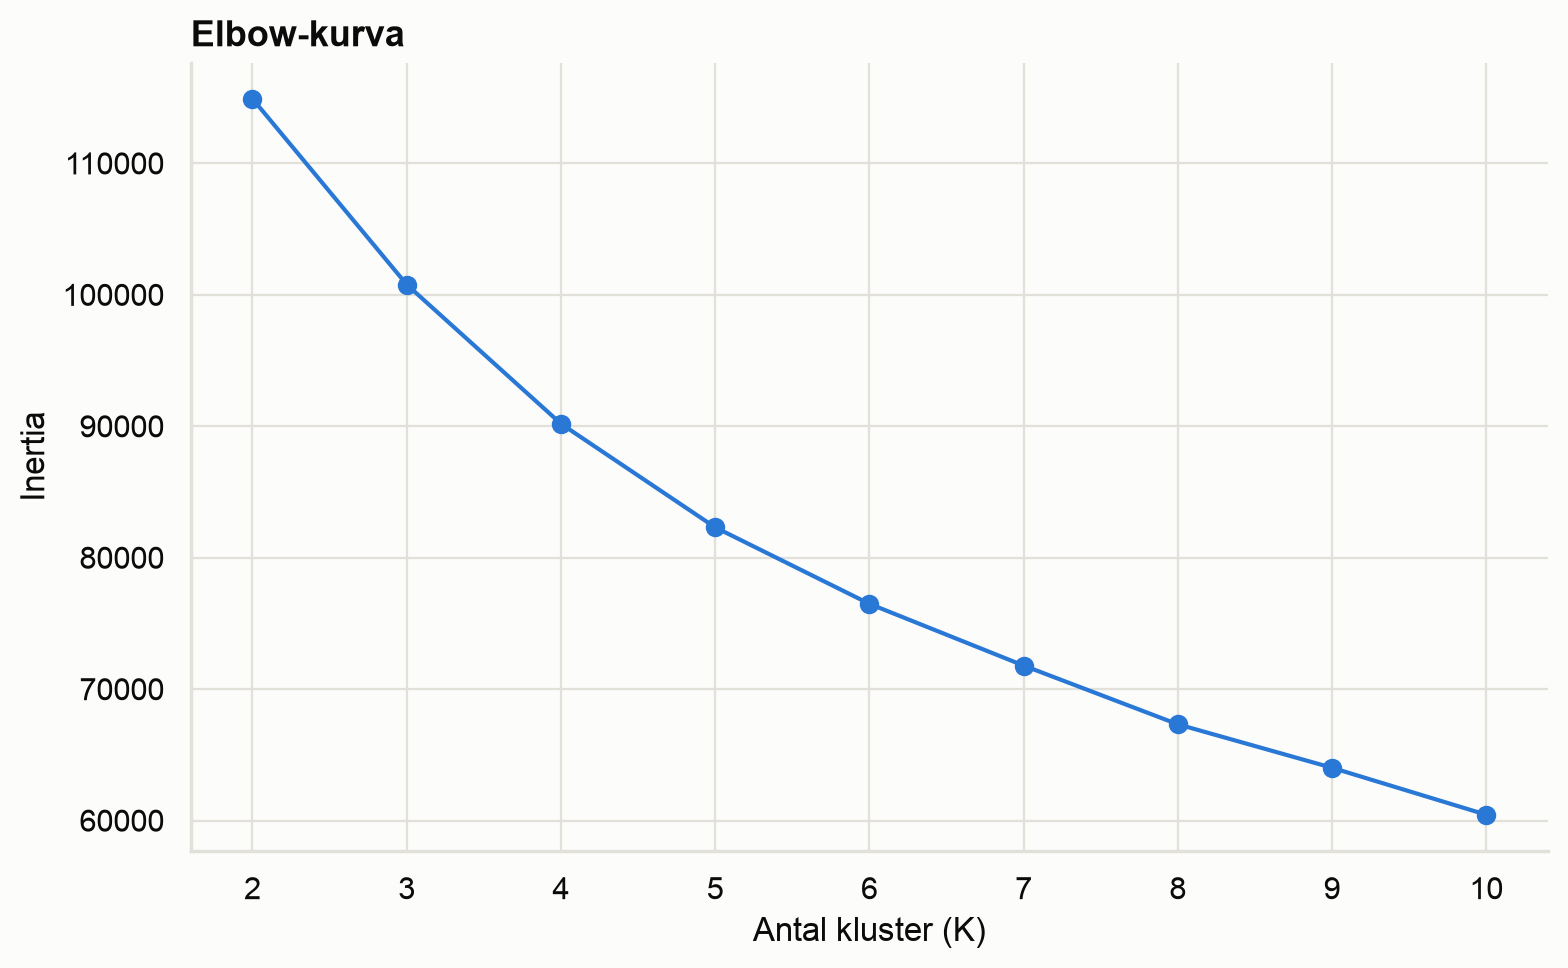

In [5]:
# Elbow-kurva: inertia (summan av kvadratavstånd inom varje kluster) mot K.
# Letar efter "armbågen" - punkten där kurvan slutar sjunka brant och plattar ut.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), inertias, marker="o", color=PALETTE["blue"])
ax.set_xlabel("Antal kluster (K)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow-kurva")
plt.tight_layout()
plt.show()

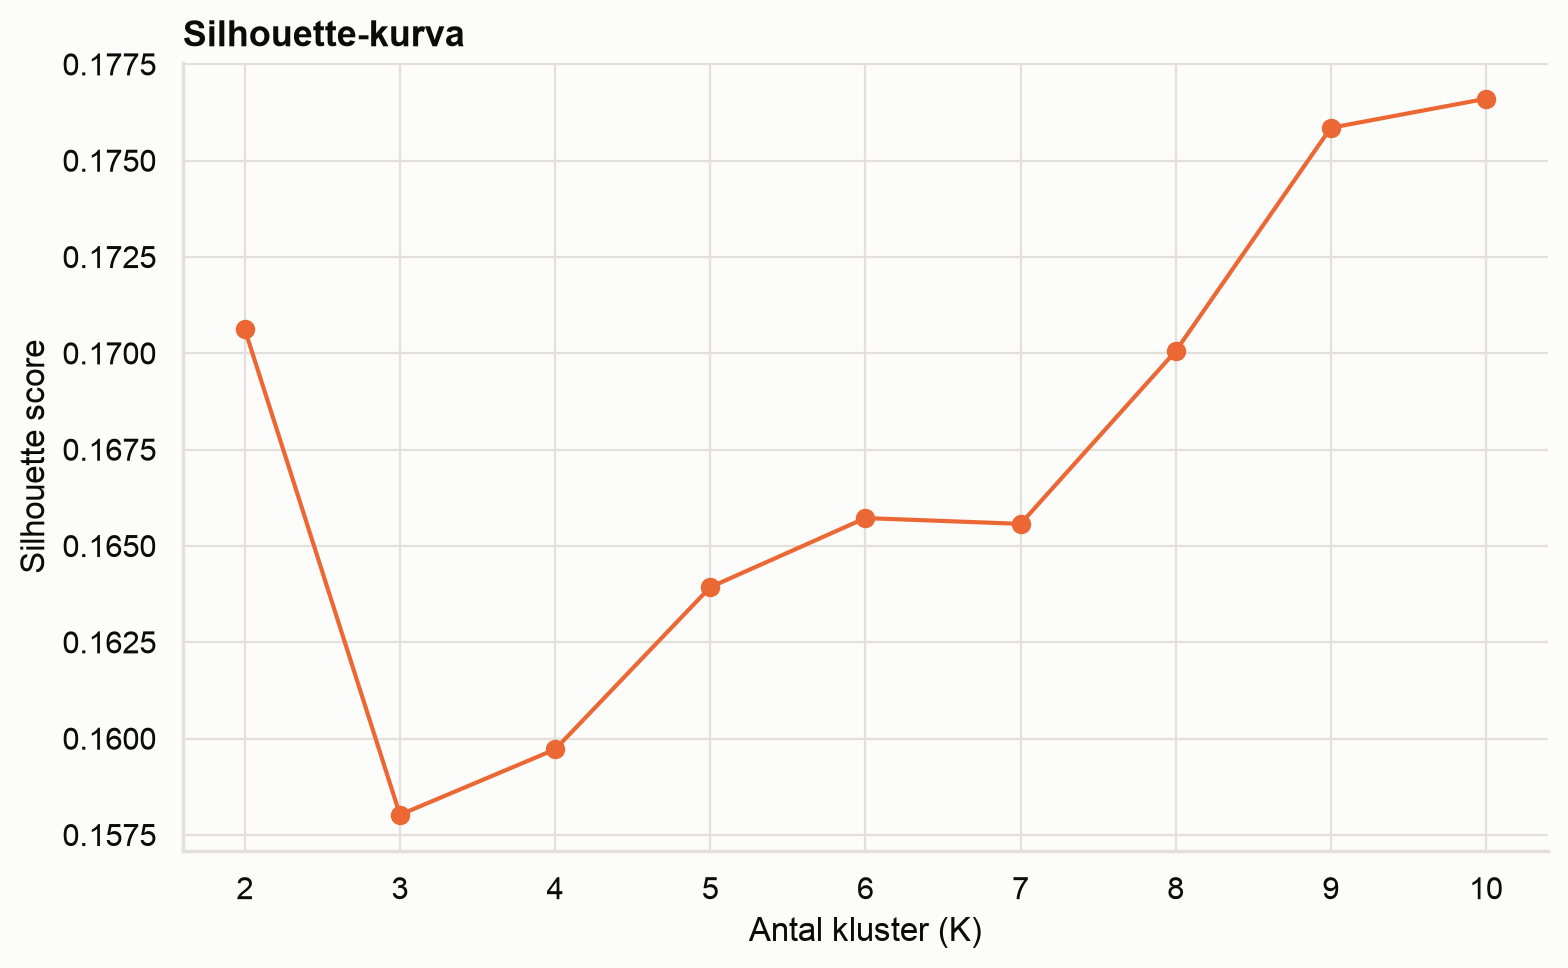

In [6]:
# Silhouette score: hur väl varje punkt passar i sitt eget kluster jämfört med
# närmaste andra kluster. Går från -1 till 1 - högre är bättre.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_values), silhouettes, marker="o", color=PALETTE["orange"])
ax.set_xlabel("Antal kluster (K)")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette-kurva")
plt.tight_layout()
plt.show()

In [7]:
# Stabilitetstest: kör samma K med olika slumpfrön och mät hur lika indelningarna blir.
# ARI (Adjusted Rand Index) = 1.0 betyder identisk indelning, 0 betyder slumpmässig.
# Om det finns äkta grupper i datan hittar KMeans dem oavsett var den startar - då ligger
# ARI nära 1. Låg ARI betyder att gränserna beror på slumpen, dvs svag klusterstruktur.
for k in [2, 4, 10]:
    labels = [KMeans(n_clusters=k, random_state=s, n_init=10).fit_predict(X_scaled)
              for s in (0, 1, 2)]
    pairs = [(0, 1), (0, 2), (1, 2)]
    ari = np.mean([adjusted_rand_score(labels[i], labels[j]) for i, j in pairs])
    print(f"K={k:>2}: ARI {ari:.3f}")

K= 2: ARI 0.998


K= 4: ARI 0.737


K=10: ARI 0.426


**Val av K: 4.**

Det första att konstatera är att kurvorna **inte** pekar ut något självklart K:

- **Elbow-kurvan har ingen tydlig armbåge.** Inertian minskar jämnt (12.3% → 10.5% →
  8.7% → 7.1% → 6.1% ...) utan något knäck.
- **Silhouette är genomgående låg (0.16-0.18)** och stiger dessutom svagt mot K=10. Som
  tumregel betyder värden under ~0.25 att det inte finns någon tydlig klusterstruktur.
  Att den stiger med K är typiskt för just det: KMeans skär upp ett sammanhängande moln
  i allt finare bitar, och varje bit blir kompaktare per definition - inte för att
  bitarna motsvarar verkliga grupper.
- **Stabilitetstestet** visar samma sak: K=2 ger nästan identisk indelning oavsett
  slumpfrö (ARI ≈ 1.00), medan K=4 vinglar (≈ 0.74) och K=10 är i praktiken godtycklig
  (≈ 0.43).

Det stämmer med `02_EDA.ipynb`, där livsstilsvariablerna knappt korrelerade med varandra
(mest under 0.15). Utan inbördes samband finns ingen dold struktur att gruppera -
studenterna ligger utspridda i ett kontinuum snarare än i tydliga klumpar.

**Eftersom måtten inte avgör blir valet vårt att motivera på andra grunder.** Syftet med
det här steget är att *generera hypoteser* om datan. Då väger vi in vad de olika
indelningarna faktiskt lär oss:

- **K=2** ger den mest robusta indelningen, men delar bara upp datan efter stressnivå -
  vilket korrelationsanalysen i `02_EDA.ipynb` redan visat. Bekräftande, men inget nytt.
- **K=4** delar dessutom upp högstress-gruppen efter sömn, vilket lyfter fram ett mönster
  som ingen enskild variabel visade. Det ger oss något konkret att gå vidare och pröva.

Vi väljer **K=4** och redovisar öppet att indelningen inte är helt stabil (ARI ≈ 0.74).
Klustren ska därför läsas som **hypoteser att undersöka vidare**, inte som fasta
segment - och i Sektion 5 prövar vi det viktigaste mönstret direkt mot datan, utan att
gå via klustringen.

## Sektion 3 – Träna KMeans

In [8]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_scaled)
df["Cluster"] = kmeans.labels_

df["Cluster"].value_counts().sort_index()

Cluster
0    6630
1    7197
2    7454
3    6561
Name: count, dtype: int64

## Sektion 4 – PCA-visualisering

Fem variabler går inte att rita direkt - PCA komprimerar dem till 2 dimensioner (de
riktningar som fångar mest varians) så vi kan se klustren visuellt.

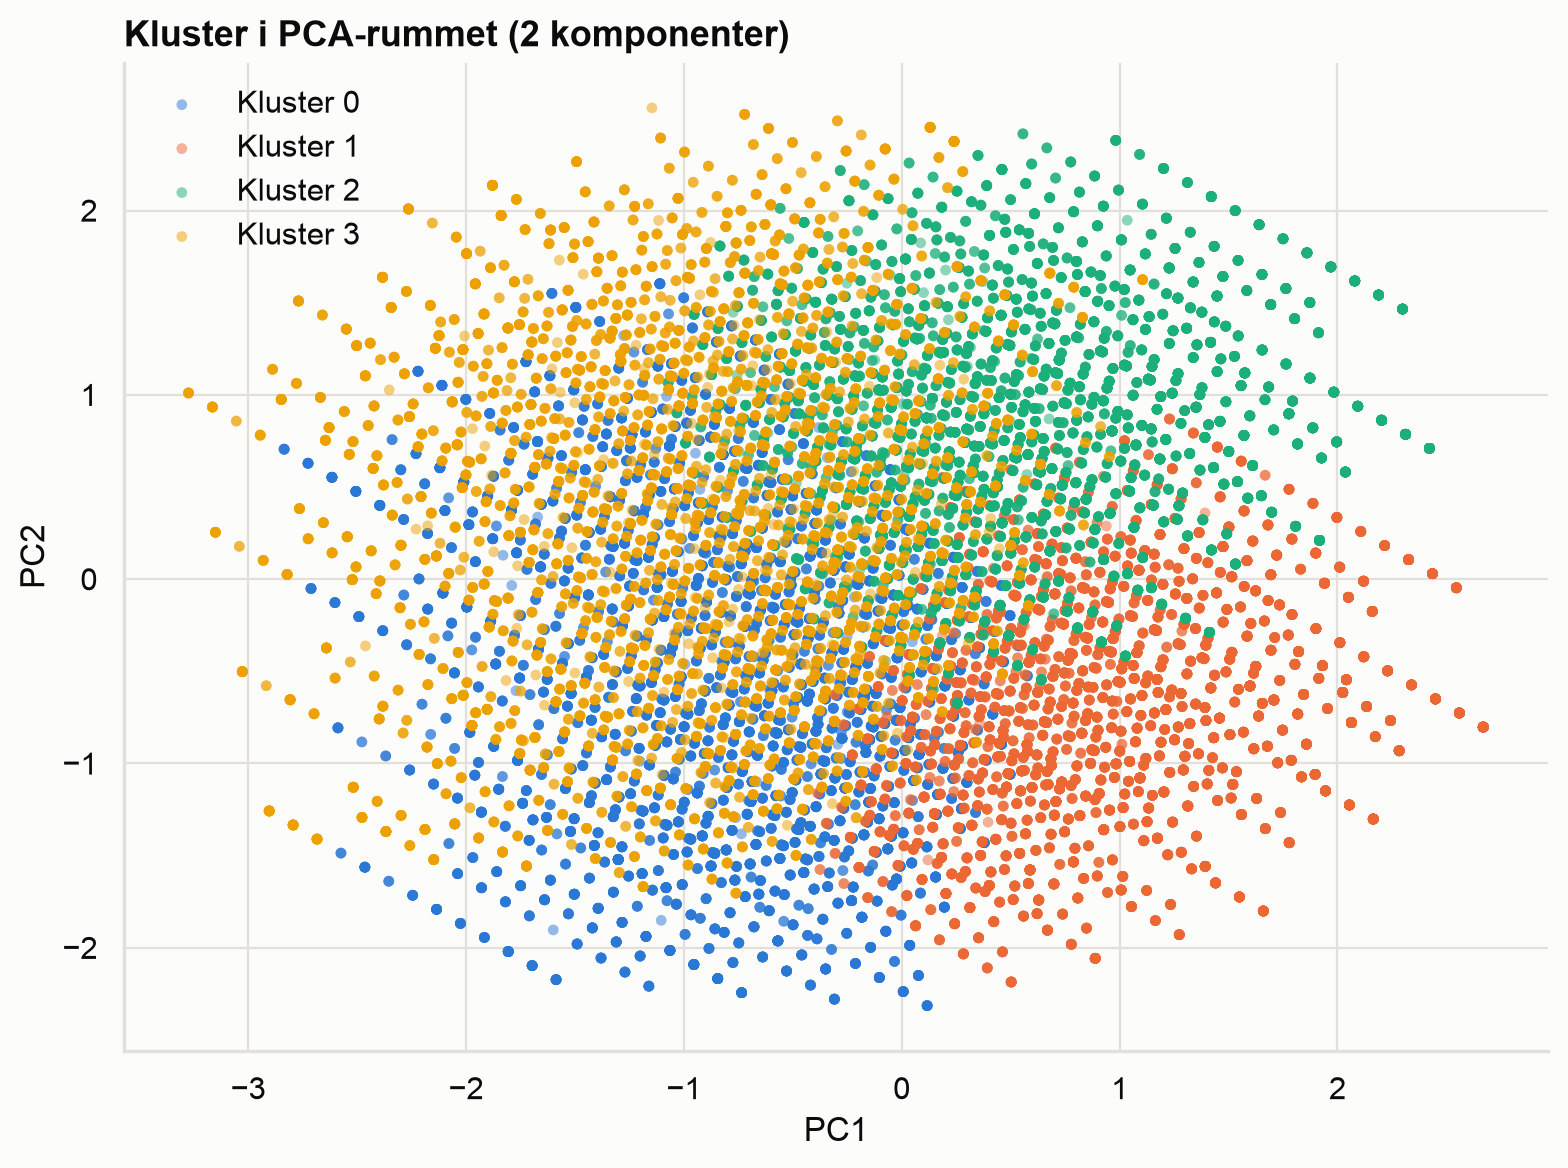

In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for cluster_id in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=CLUSTER_COLORS[cluster_id], label=f"Kluster {cluster_id}",
        alpha=0.5, s=15, edgecolors="none",
    )
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Kluster i PCA-rummet (2 komponenter)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [10]:
explained = pca.explained_variance_ratio_
print(f"PC1 förklarar {explained[0]*100:.1f}% av variansen")
print(f"PC2 förklarar {explained[1]*100:.1f}% av variansen")
print(f"Tillsammans: {explained.sum()*100:.1f}%")

PC1 förklarar 25.6% av variansen
PC2 förklarar 20.2% av variansen
Tillsammans: 45.8%


## Sektion 5 – Koppla kluster till Depression

Nu tar vi fram `Depression` igen - bara för att UTVÄRDERA klustren i efterhand, inte
för att de påverkat hur klustren bildades.

In [11]:
# normalize="index" - för varje kluster (raden), hur stor andel har Depression=0 vs 1?
pd.crosstab(df["Cluster"], df["Depression"], normalize="index")

Depression,0,1
Cluster,,
0,0.684163,0.315837
1,0.144783,0.855217
2,0.224712,0.775288
3,0.653254,0.346746


In [12]:
# Gruppmedelvärden i OSKALADE värden (originalskalan) - lättare att tolka än
# standardiserade z-värden, t.ex. "medel-sömnkod 2.3" istället för "-0.15 std".
df.groupby("Cluster")[lifestyle_cols].mean().round(2)

,Academic Pressure,Financial Stress,Sleep Duration,Dietary Habits,Work/Study Hours
Cluster,,,,,
0,2.14,2.01,2.23,2.29,9.10
1,3.93,3.93,1.34,1.67,8.54
2,3.73,3.77,3.49,1.70,8.59
3,2.63,2.71,2.49,2.00,2.06


### Pröva klustringens hypotes direkt mot datan

Klustren 1 och 2 har nästan identisk press- och stressnivå men olika sömn, och skiljer
sig i Depression-andel. Det är en hypotes: *sömn spelar roll även när stressen är lika hög.*

Eftersom indelningen inte är helt stabil (ARI ≈ 0.74) bör vi inte lita på klustringen
ensam. Här prövar vi mönstret utan att gå via KMeans - vi delar bara upp studenterna
efter summan press + ekonomisk stress och tittar på sömn inom varje nivå.

In [13]:
# Enkel stressnivå: summan av de två variabler som klustringen faktiskt delade efter.
stress_sum = df["Academic Pressure"] + df["Financial Stress"]
hog_stress = df[stress_sum >= 7]
lag_stress = df[stress_sum <= 5]

jamforelse = pd.DataFrame({
    "Hög stress (%)": hog_stress.groupby("Sleep Duration")["Depression"].mean() * 100,
    "Låg stress (%)": lag_stress.groupby("Sleep Duration")["Depression"].mean() * 100,
}).round(1)
jamforelse.index = ["<5h", "5-6h", "7-8h", ">8h"]
jamforelse

,Hög stress (%),Låg stress (%)
<5h,87.7,31.0
5-6h,81.5,25.9
7-8h,83.6,26.4
>8h,78.2,19.7


## Sektion 6 – Slutsatser

**Vad karaktäriserar varje kluster** (gruppmedelvärden ovan, oskalade värden):

| Kluster | n | Press | Ek. stress | Sömn | Kost | Timmar | Depression |
|---|---|---|---|---|---|---|---|
| 1 | 7 197 | 3.93 | 3.93 | **1.34** (<5h) | 1.67 | 8.54 | **85.5%** |
| 2 | 7 454 | 3.73 | 3.77 | **3.49** (7-8h) | 1.70 | 8.59 | **77.5%** |
| 3 | 6 561 | 2.63 | 2.71 | 2.49 | 2.00 | **2.06** (få) | 34.7% |
| 0 | 6 630 | 2.14 | 2.01 | 2.23 | 2.29 | **9.10** (många) | 31.6% |

Grovt sett: **kluster 1 och 2 är högstress-grupper, kluster 0 och 3 är lågstress-grupper.**
Inom varje par är det en annan variabel som skiljer dem åt - sömn för högstress-paret,
arbets-/studietimmar för lågstress-paret.

**Hänger klustren ihop med Depression?** Ja, mycket tydligt - trots att vi aldrig visade
klustringen `Depression`-kolumnen. Andelen varierar från 31.6% till 85.5%, alltså nästan
54 procentenheter. Det är betydligt mer än vad någon enskild variabel gav i
`02_EDA.ipynb` (starkast där var Academic Pressure med korrelation 0.47). Att väga ihop
press och ekonomisk stress skiljer alltså grupperna åt bättre än någon av dem gör ensam.

**Hypotesen klustringen genererade - och hur den stod sig.** Kluster 1 och 2 har nästan
identisk stressnivå men olika sömn och skiljer sig 8 procentenheter i Depression. Vi
prövade det direkt mot datan (tabellen ovan) och sömnmönstret höll:

- Bland högstress-studenter: 87.7% (<5h) ned till 78.2% (>8h)
- Bland lågstress-studenter: 31.0% (<5h) ned till 19.7% (>8h)

Men prövningen gav också en **korrigering**: effekten är ungefär lika stor i båda
grupperna (~10 procentenheter). Sömn är alltså inte en skyddsfaktor som specifikt
dämpar hög stress, utan har en generell och ganska konstant koppling till Depression.
Det hade vi trott felaktigt om vi bara läst av klustren. Notera också att mönstret inte
är helt regelbundet - 7-8h ligger sämre till än 5-6h i båda grupperna, samma
oregelbundenhet som vi såg redan i EDA:n.

**Vad klustringen INTE visade.** Silhouette låg runt 0.16-0.18 genom hela intervallet och
ARI för K=4 var 0.74 - studenterna bildar alltså inte fyra distinkta livsstilstyper, utan
ligger utspridda längs ett kontinuum där stressnivå är den dominerande riktningen. Det
syns i PCA-plotten, där klustren rinner ihop utan tomrum. Att två komponenter bara
förklarar 45.8% av variansen pekar åt samma håll: informationen är spridd över alla fem
variabler snarare än samlad i några få riktningar.

**Vad tar vi med oss till supervised-steget (steg 4)?**
- Academic Pressure och Financial Stress är de variabler klustringen faktiskt organiserade
  datan efter - de bör vara centrala i modellerna.
- De två tillsammans skiljer grupperna åt bättre än var för sig. Värt att testa en
  kombinerad stress-poäng (summan av de två) som en egen variabel.
- Sleep Duration ser svag ut i korrelationsmått men har en konsekvent koppling på ~10
  procentenheter när man håller stressnivån konstant. Värd att behålla i modellerna,
  trots den låga korrelationen.
- `Cluster` som egen variabel är däremot troligen redundant - den bär i stort sett samma
  information som Academic Pressure och Financial Stress redan gör, fast grövre.
- Låga silhouette-värden betyder inte att steget var bortkastat: klustringen pekade ut en
  hypotes vi annars hade missat, och tvingade fram en prövning som både bekräftade och
  korrigerade den.